# HDB Resale Price Regression — Notebook 19: Story Charts

ggplot charts for the published story. All based on Model 11 (85 variables, no interactions).

In [1]:
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

Error importing in API mode: ImportError("dlopen(/Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


In [2]:
%%R
library(tidyverse)
library(lubridate)

df <- read_csv('data/hdb_resale_full.csv', show_col_types = FALSE)
df$month <- as.Date(df$month)
df$remaining_lease_sq <- df$remaining_lease_years^2
df$block_has_4 <- as.integer(grepl('4', df$block))

# Trailing 8s count
df$num_eights_tail <- sapply(as.character(as.integer(df$resale_price)), function(s) {
    n <- nchar(s)
    count <- 0
    for (i in n:1) { if (substr(s, i, i) == '8') count <- count + 1 else break }
    count
})

cat(sprintf('Loaded %s rows, %s to %s\n',
    format(nrow(df), big.mark=','),
    min(df$month), max(df$month)))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loaded 976,261 rows, 1990-01-01 to 2026-04-01


## Chart 1: Superstition effects over time

Run Model 11 on each two-year window separately. Plot the block-4 penalty (drops below zero) and trailing-8 premium (stays above zero) in dollar terms.

Replaces the earlier Datawrapper chart that plotted both effects as positive percentages, which was confusing because a penalty and a premium both went up.

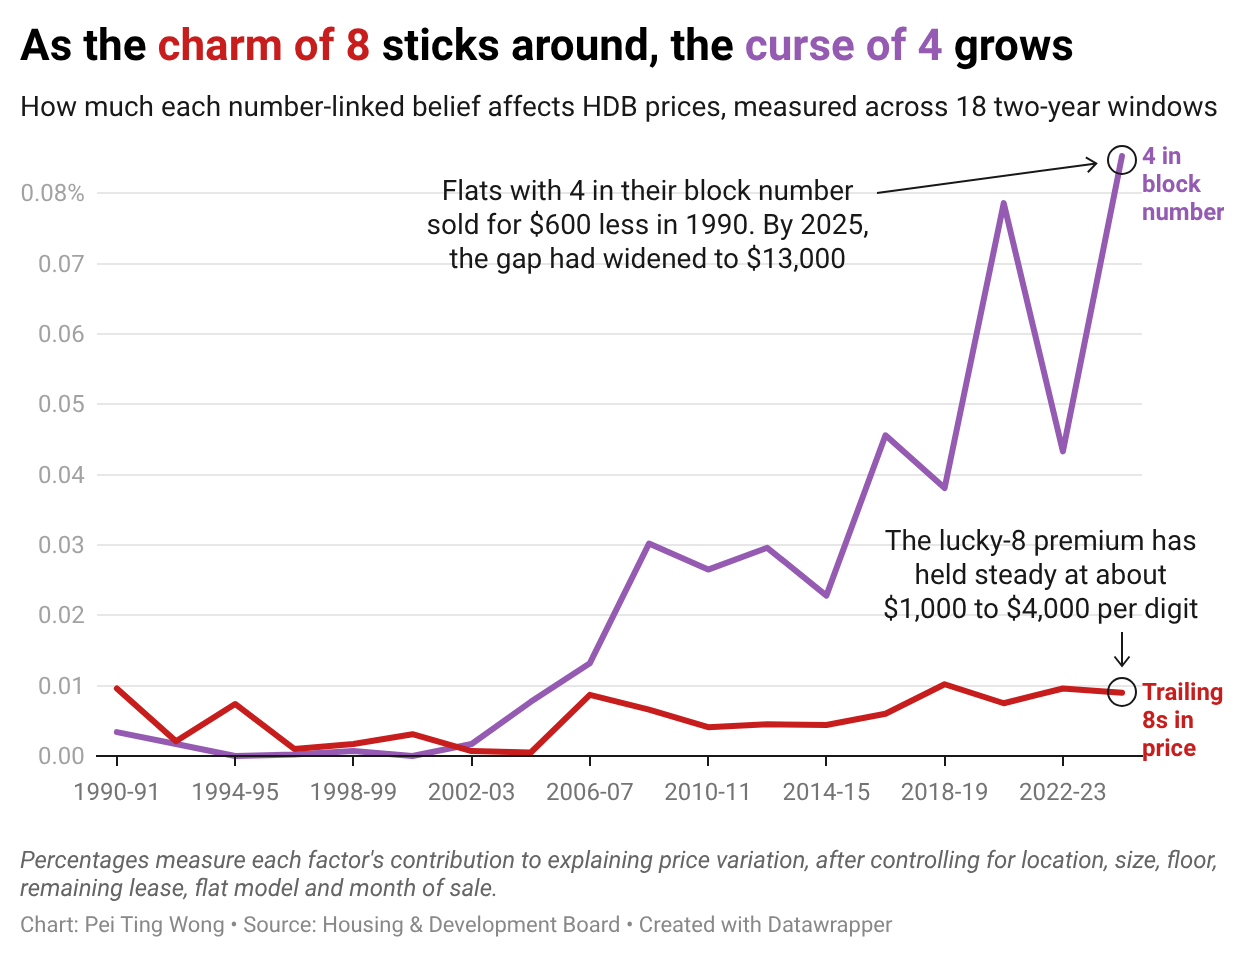

In [3]:
# the old chart for comparison
from IPython.display import Image
Image(filename='charts/datawrapper_superstition_v1.png')

In [4]:
%%R
# Run Model 11 on each two-year window
starts <- as.Date(paste0(seq(1990, 2024, 2), '-01-01'))
results <- list()

for (s in seq_along(starts)) {
    s_date <- starts[s]
    e_date <- s_date + years(2) - days(1)
    sub <- df[df$month >= s_date & df$month <= e_date, ]
    if (nrow(sub) < 500) next
    
    sub$month_factor <- factor(format(sub$month, '%Y-%m'))
    
    tryCatch({
        m <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
                remaining_lease_years + remaining_lease_sq +
                num_eights_tail + block_has_4 +
                month_factor,
              data = sub)
        
        coefs <- summary(m)$coefficients
        label <- sprintf('%d-%02d', year(s_date), (year(s_date)+1) %% 100)
        
        results[[length(results) + 1]] <- data.frame(
            period = label,
            mid_year = year(s_date) + 1,
            block4 = coefs['block_has_4', 'Estimate'],
            block4_p = coefs['block_has_4', 'Pr(>|t|)'],
            trail8 = coefs['num_eights_tail', 'Estimate'],
            trail8_p = coefs['num_eights_tail', 'Pr(>|t|)'],
            n = nrow(sub),
            mean_price = mean(sub$resale_price)
        )
    }, error = function(e) cat(sprintf('Error %s: %s\n', year(s_date), e$message)))
}

results <- bind_rows(results)

cat(sprintf('%-10s %6s %10s %6s %10s %6s\n', 'Period', 'N', 'Block4', 'p', 'Trail8', 'p'))
for (i in 1:nrow(results)) {
    r <- results[i, ]
    cat(sprintf('%-10s %6d $%+9.0f %6.4f $%+9.0f %6.4f\n',
        r$period, r$n, r$block4, r$block4_p, r$trail8, r$trail8_p))
}

Period          N     Block4      p     Trail8      p


1990-91     25360 $     -795 0.0001 $    +2516 0.1551


1992-93     32619 $     -901 0.0044 $    +8646 0.0002


1994-95     53662 $      +86 0.7149 $    +2741 0.0111


1996-97     66678 $     -270 0.2537 $    +1107 0.1284


...

2016-17     39882 $    -8998 0.0000 $    +1400 0.0017


2018-19     43747 $    -7891 0.0000 $    +1865 0.0001


2020-21     52420 $   -10608 0.0000 $    +1361 0.0003


2022-23     52474 $    -8643 0.0000 $    +1694 0.0000


2024-25     52918 $   -14070 0.0000 $    +1541 0.0000


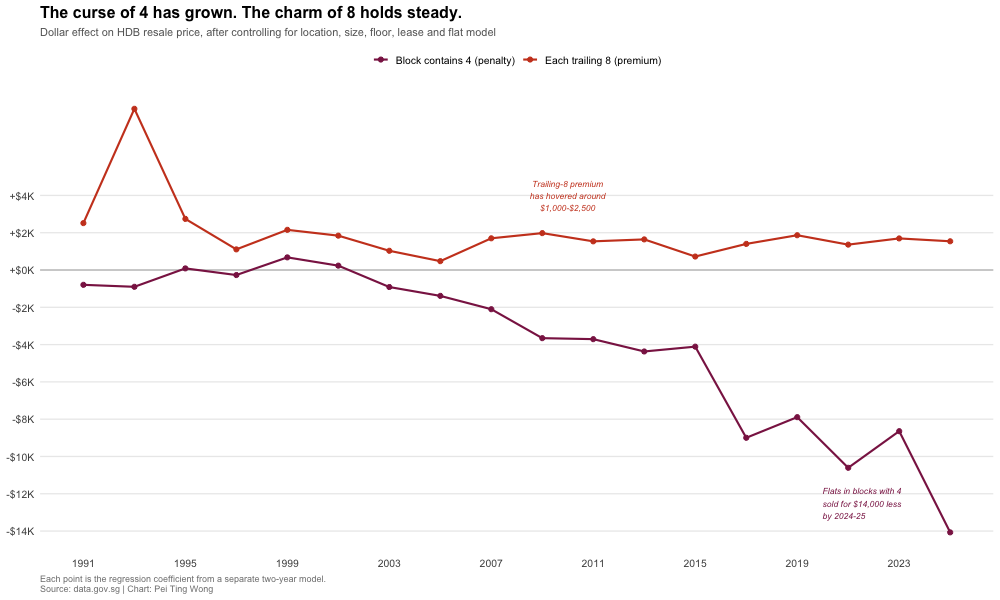

In [5]:
%%R -w 1000 -h 600

long <- results %>%
    select(period, mid_year, block4, trail8) %>%
    pivot_longer(cols = c(block4, trail8), names_to = 'effect', values_to = 'dollars') %>%
    mutate(
        label = ifelse(effect == 'block4', 'Block number contains 4', 'Each trailing 8 in price'),
        dollars = dollars / 1000
    )

ggplot(long, aes(x = mid_year, y = dollars, colour = effect)) +
    geom_hline(yintercept = 0, colour = 'grey70', linewidth = 0.5) +
    geom_line(linewidth = 1) +
    geom_point(size = 2) +
    scale_colour_manual(
        values = c('block4' = '#8B2252', 'trail8' = '#CC4422'),
        labels = c('block4' = 'Block contains 4 (penalty)', 'trail8' = 'Each trailing 8 (premium)')
    ) +
    scale_x_continuous(breaks = seq(1991, 2025, 4)) +
    scale_y_continuous(
        labels = function(x) ifelse(x >= 0, paste0('+$', abs(x), 'K'), paste0('-$', abs(x), 'K')),
        breaks = seq(-14, 4, 2)
    ) +
    labs(
        title = 'The curse of 4 has grown. The charm of 8 holds steady.',
        subtitle = 'Dollar effect on HDB resale price, after controlling for location, size, floor, lease and flat model',
        x = NULL, y = NULL,
        caption = 'Each point is the regression coefficient from a separate two-year model.\nSource: data.gov.sg | Chart: Pei Ting Wong'
    ) +
    annotate('text', x = 2020, y = -12.5,
        label = 'Flats in blocks with 4\nsold for $14,000 less\nby 2024-25',
        size = 3, colour = '#8B2252', fontface = 'italic', hjust = 0) +
    annotate('text', x = 2010, y = 4,
        label = 'Trailing-8 premium\nhas hovered around\n$1,000-$2,500',
        size = 3, colour = '#CC4422', fontface = 'italic', hjust = 0.5) +
    theme_minimal(base_size = 13) +
    theme(
        legend.position = 'top',
        legend.title = element_blank(),
        plot.title = element_text(face = 'bold', size = 16),
        plot.subtitle = element_text(colour = 'grey40', size = 11),
        plot.caption = element_text(colour = 'grey50', size = 9, hjust = 0),
        panel.grid.minor = element_blank(),
        panel.grid.major.x = element_blank()
    )

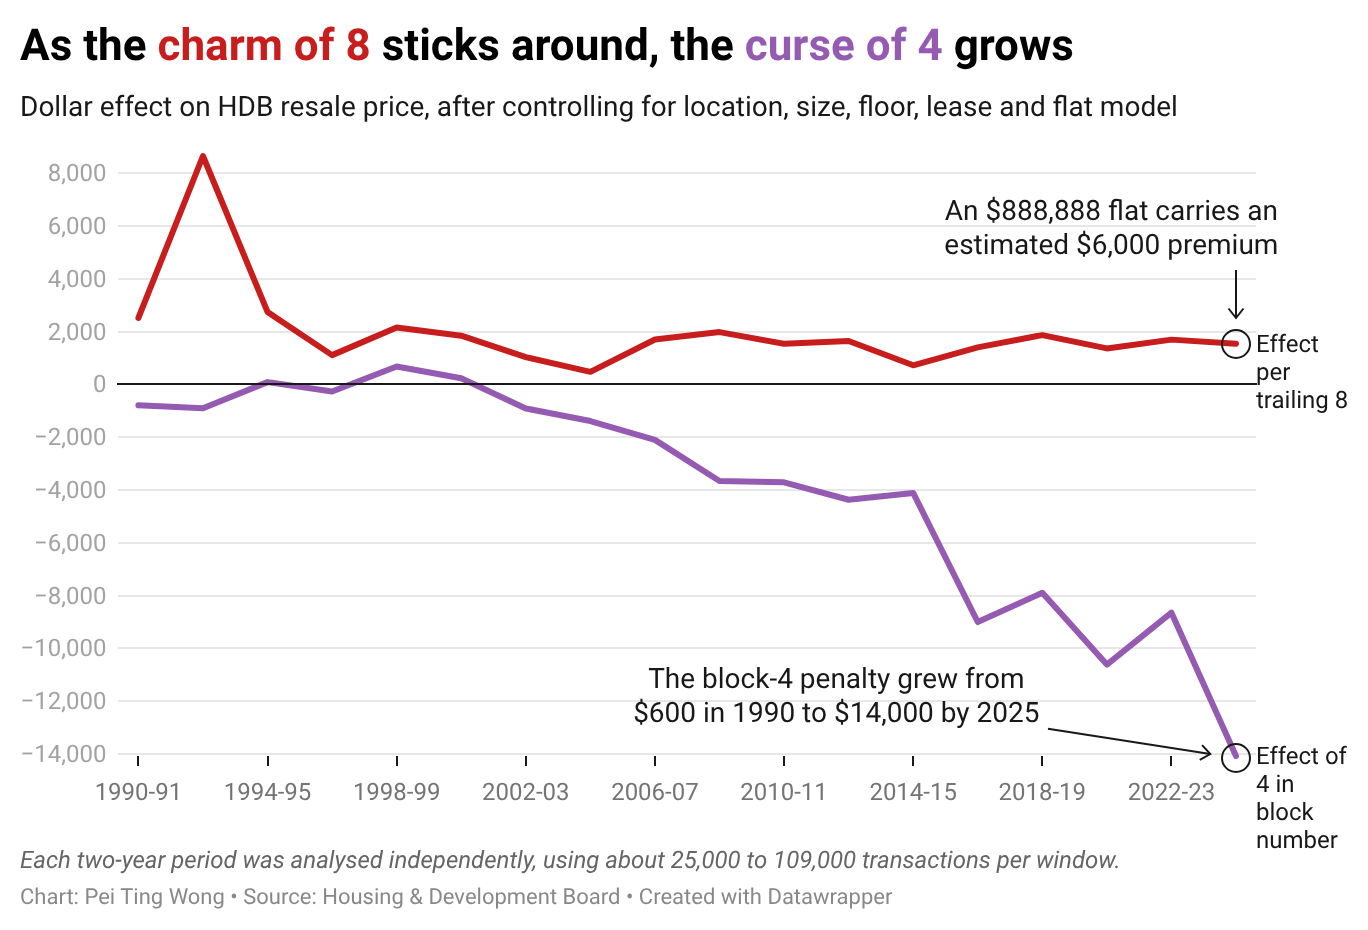

In [6]:
# Reproduced in Datawrapper

from IPython.display import Image
Image(filename='charts/datawrapper_superstition_v2.png')

## Chart 2: Lucky-8 premium by price quartile

Let's use raw prices not percentages, center at zero to emphasise deviations from prediction, and do custom ggplot.

This chart shows how much more (or less) 888-ending flats sold for compared to non-888 flats in the same price band. Quartiles are based on predicted price from a model **without** superstition variables, so the grouping is independent of the 8s.

Key finding: at the cheap end (Q1), pricing with 888 **hurts** — sellers leave about $3,500 on the table. At Q2–Q4, it helps.

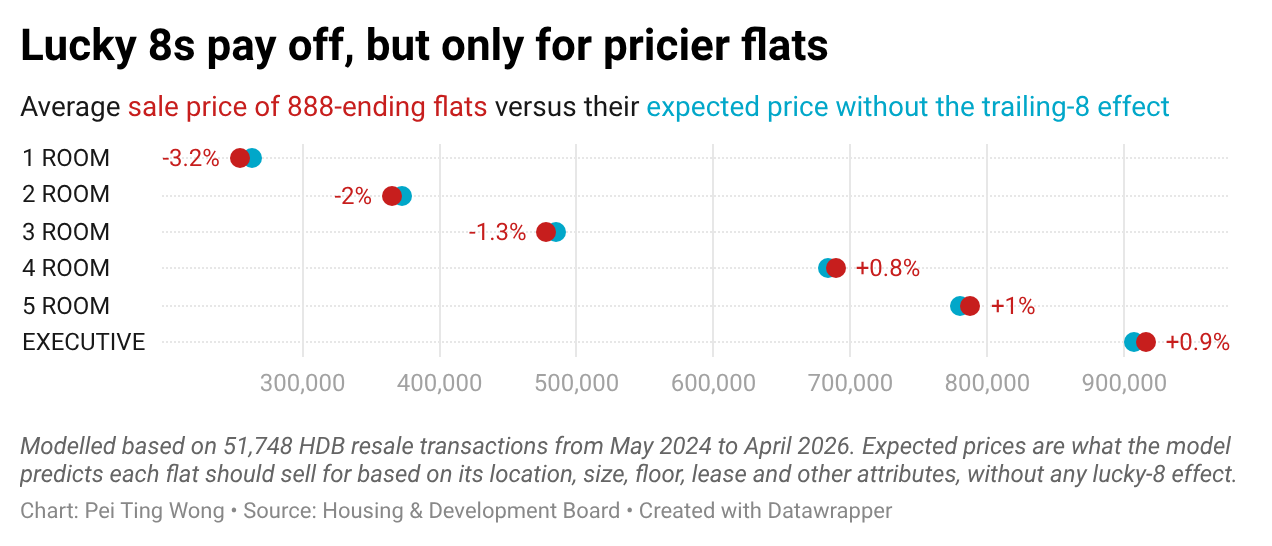

In [7]:
# the old chart for comparison
from IPython.display import Image
Image(filename='charts/datawrapper_premium_v1.png')

In [8]:
%%R
# Load the 24-month analysis dataset
recent <- read_csv('data/hdb_analysis.csv', show_col_types = FALSE)
recent$remaining_lease_sq <- recent$remaining_lease_years^2
recent$remaining_lease_cu <- recent$remaining_lease_years^3
recent$month_factor <- factor(format(recent$month, '%Y-%m'))
recent$is_terrace <- ifelse(recent$flat_model_grouped == 'Terrace', 1, 0)
recent$ln_price <- log(recent$resale_price)
recent$has_8 <- recent$num_eights_tail > 0

# Model without superstition variables — for quartile assignment
# Uses the final model spec (log + terrace + cubic) minus superstition vars
model_no_super <- lm(ln_price ~ town + flat_type + floor_area_sqm * is_terrace + storey_mid +
              remaining_lease_years + remaining_lease_sq + remaining_lease_cu +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m + park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m + coast_dist_m +
              month_factor,
            data = recent)

recent$pred_no_super <- exp(predict(model_no_super, recent))
recent$resid <- recent$resale_price - recent$pred_no_super

recent$quartile <- cut(recent$pred_no_super,
    breaks = quantile(recent$pred_no_super, probs = c(0, 0.25, 0.5, 0.75, 1), na.rm=TRUE),
    labels = c('Q1: Cheapest 25%', 'Q2', 'Q3', 'Q4: Most expensive 25%'),
    include.lowest = TRUE)

# 888 premium per quartile
premium <- recent %>%
    filter(!is.na(quartile)) %>%
    group_by(quartile, has_8) %>%
    summarise(mean_resid = mean(resid), n = n(), .groups = 'drop') %>%
    pivot_wider(names_from = has_8, values_from = c(mean_resid, n)) %>%
    mutate(premium = mean_resid_TRUE - mean_resid_FALSE)

cat(sprintf('%-25s %8s %8s %10s\n', 'Quartile', 'N(888)', 'N(other)', 'Premium'))
for (i in 1:nrow(premium)) {
    r <- premium[i, ]
    cat(sprintf('%-25s %8d %8d $%+8.0f\n',
        as.character(r$quartile), r$n_TRUE, r$n_FALSE, r$premium))
}

Quartile                    N(888) N(other)    Premium


Q1: Cheapest 25%              2667    10268 $    +517


Q2                            2804    10131 $   +4780


Q3                            3224     9711 $   +7117


Q4: Most expensive 25%        3405     9530 $   +6134


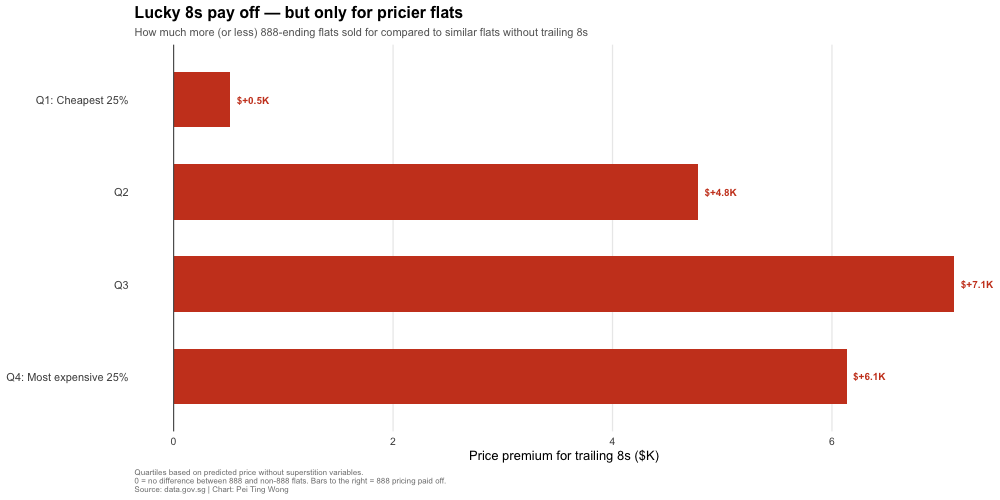

In [9]:
%%R -w 1000 -h 500

ggplot(premium, aes(x = fct_rev(quartile), y = premium / 1000)) +
    geom_col(aes(fill = premium > 0), width = 0.6, show.legend = FALSE) +
    geom_hline(yintercept = 0, colour = 'grey30', linewidth = 0.5) +
    geom_text(aes(label = sprintf('$%+.1fK', premium/1000),
                  hjust = ifelse(premium > 0, -0.2, 1.2)),
              size = 3.5, fontface = 'bold',
              colour = ifelse(premium$premium > 0, '#CC4422', '#2255AA')) +
    scale_fill_manual(values = c('TRUE' = '#CC4422', 'FALSE' = '#2255AA')) +
    coord_flip() +
    labs(
        title = 'Lucky 8s pay off \u2014 but only for pricier flats',
        subtitle = 'How much more (or less) 888-ending flats sold for compared to similar flats without trailing 8s',
        x = NULL,
        y = 'Price premium for trailing 8s ($K)',
        caption = 'Quartiles based on predicted price without superstition variables.\n0 = no difference between 888 and non-888 flats. Bars to the right = 888 pricing paid off.\nSource: data.gov.sg | Chart: Pei Ting Wong'
    ) +
    theme_minimal(base_size = 13) +
    theme(
        plot.title = element_text(face = 'bold', size = 16),
        plot.subtitle = element_text(colour = 'grey40', size = 11),
        plot.caption = element_text(colour = 'grey50', size = 8, hjust = 0),
        panel.grid.major.y = element_blank(),
        panel.grid.minor = element_blank(),
        axis.text.y = element_text(size = 11)
    )

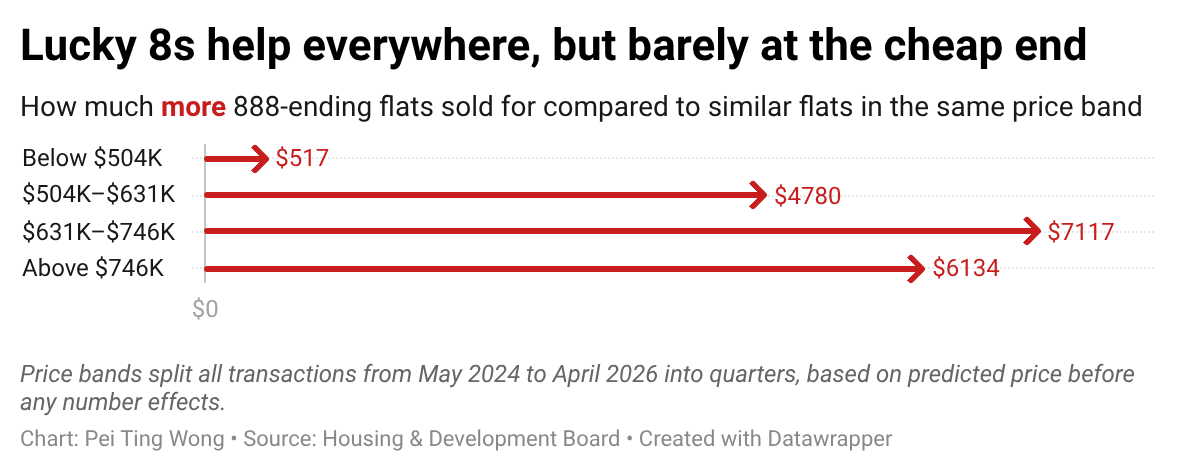

In [10]:
# final chart reproduced in Datawrapper
from IPython.display import Image
Image(filename='charts/datawrapper_premium_v2.png')

## Stress test: High vs low end within each flat type

Question: are there high-end 1-rooms and low-end 5-rooms? Is this really about price level, not flat type?

Within each flat type, split into above/below median predicted price and check the 888 premium. If the effect is about price level, we should see the lower half penalised and the upper half rewarded **within** the same flat type.

In [11]:
%%R

stress <- recent %>%
    filter(!is.na(quartile), flat_type %in% c('2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', 'EXECUTIVE')) %>%
    group_by(flat_type) %>%
    mutate(above_median = pred_no_super > median(pred_no_super)) %>%
    ungroup() %>%
    group_by(flat_type, above_median, has_8) %>%
    summarise(n = n(), mean_resid = mean(resid), .groups = 'drop') %>%
    pivot_wider(names_from = has_8, values_from = c(n, mean_resid)) %>%
    mutate(
        premium = mean_resid_TRUE - mean_resid_FALSE,
        segment = ifelse(above_median, 'Upper half', 'Lower half')
    ) %>%
    select(flat_type, segment, n_TRUE, premium) %>%
    arrange(flat_type, segment)

cat(sprintf('%-12s %-12s %8s %10s\n', 'Flat type', 'Segment', 'N(888)', 'Premium'))
cat(paste(rep('-', 46), collapse = ''), '\n')
for (i in 1:nrow(stress)) {
    r <- stress[i, ]
    flag <- ifelse(r$premium < 0, ' \u2190 penalty', '')
    cat(sprintf('%-12s %-12s %8d $%+8.0f%s\n',
        r$flat_type, r$segment, r$n_TRUE, r$premium, flag))
}

Flat type    Segment        N(888)    Premium


----------------------------------------------

2 ROOM       Lower half        129 $    +108


2 ROOM       Upper half        156 $   +3019


3 ROOM       Lower half       1308 $   +1712


...

4 ROOM       Upper half       3057 $   +7852


5 ROOM       Lower half       1271 $   +5728


5 ROOM       Upper half       1569 $   +3424


EXECUTIVE    Lower half        359 $   +9072


EXECUTIVE    Upper half        383 $   +5003


### Interpretation

The pattern holds cleanly for **2-room** and **3-room** flats: the lower half of each type sees a penalty for 888 pricing, the upper half sees a premium. This confirms it's about price level, not flat type.

For **4-room and above**, even the "lower half" is already in the $600K–$700K range — expensive enough that 888 carries a premium in both halves. The effect doesn't reverse because there's no truly "cheap" segment within these flat types.

**What's happening at the low end?** Cheap flats priced with 888 endings are likely overpriced — sellers reach for an auspicious number but the buyer pool at that price point won't pay extra for it. A $350,000 flat priced at $358,888 signals aspiration, not value. The buyer negotiates down or walks. At the expensive end, buyers who can afford $800K+ are more willing to meet a psychologically curated price.

## Datawrapper arrow maps

Generate all arrow map CSVs for Datawrapper. Uses the final model (log + terrace + cubic lease) to compute residuals. Arrows point up when a flat sold above prediction, down when below.

In [12]:
%%R
# Final model
recent <- read_csv('data/hdb_analysis.csv', show_col_types = FALSE)
recent$remaining_lease_sq <- recent$remaining_lease_years^2
recent$remaining_lease_cu <- recent$remaining_lease_years^3
recent$month_factor <- factor(format(recent$month, '%Y-%m'))
recent$is_terrace <- ifelse(recent$flat_model_grouped == 'Terrace', 1, 0)
recent$ln_price <- log(recent$resale_price)

model_final <- lm(ln_price ~ town + flat_type + floor_area_sqm * is_terrace + storey_mid +
              remaining_lease_years + remaining_lease_sq + remaining_lease_cu +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m + park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m + coast_dist_m +
              num_eights_tail + block_has_4 +
              month_factor, data = recent)

recent$predicted <- round(exp(predict(model_final, recent)))
recent$residual <- round(recent$resale_price - recent$predicted)

# Categories
recent$is_168 <- (recent$resale_price >= 1168000 & recent$resale_price <= 1168888)
recent$is_888 <- (recent$resale_price == 888888)
recent$has_trail_8 <- (recent$num_eights_tail > 0)
recent$category <- 'Other'
recent$category[recent$block_has_4 == 1] <- 'Block has 4'
recent$category[recent$has_trail_8] <- 'Trailing 8s'
recent$category[recent$is_888] <- '$888,888'
recent$category[recent$is_168] <- '$1,168,000'

base <- recent %>%
    filter(!is.na(latitude) & !is.na(longitude)) %>%
    select(latitude, longitude, residual, category,
           resale_price, predicted, block, street_name, flat_type,
           storey_range, floor_area_sqm)

# === Million-dollar trailing-8 flats (main map) ===
out_million <- base %>%
    filter(category != 'Other' & category != 'Block has 4' & resale_price >= 1000000) %>%
    filter(floor_area_sqm <= 200)  # exclude terrace outlier
write_csv(out_million, 'charts/datawrapper_arrow_map_million.csv')

# === 168 only ===
out_168 <- base %>% filter(category == '$1,168,000')
write_csv(out_168, 'charts/datawrapper_arrow_map_168.csv')

# === Highlights (168 + 888) ===
out_highlights <- base %>% filter(category %in% c('$1,168,000', '$888,888'))
write_csv(out_highlights, 'charts/datawrapper_arrow_map_highlights.csv')

# === 888 endings (3+ trailing 8s) ===
price_str <- as.character(as.integer(recent$resale_price))
recent$n_trail_8 <- sapply(price_str, function(s) {
    n <- nchar(s); count <- 0
    for (i in n:1) { if (substr(s,i,i)=='8') count <- count+1 else break }
    count
})
out_888 <- recent %>%
    filter(!is.na(latitude) & !is.na(longitude)) %>%
    filter(n_trail_8 >= 3 | is_168) %>%
    select(latitude, longitude, residual, category, resale_price)
write_csv(out_888, 'charts/datawrapper_arrow_map_888.csv')

# === All trailing 8s (no block-4) ===
out_lite <- base %>% filter(category != 'Other' & category != 'Block has 4')
write_csv(out_lite %>% select(latitude, longitude, residual, category, resale_price),
          'charts/datawrapper_arrow_map_lite.csv')

# === Full (all categories) ===
out_full <- base %>% filter(category != 'Other')
write_csv(out_full, 'charts/datawrapper_arrow_map.csv')

cat(sprintf('arrow_map_million: %d rows\n', nrow(out_million)))
cat(sprintf('arrow_map_168: %d rows, all above: %s\n', nrow(out_168), all(out_168$residual > 0)))
cat(sprintf('arrow_map_highlights: %d rows\n', nrow(out_highlights)))
cat(sprintf('arrow_map_888: %d rows\n', nrow(out_888)))
cat(sprintf('arrow_map_lite: %d rows\n', nrow(out_lite)))
cat(sprintf('arrow_map_full: %d rows\n', nrow(out_full)))

arrow_map_million: 738 rows


arrow_map_168: 24 rows, all above: TRUE


arrow_map_highlights: 51 rows


arrow_map_888: 4474 rows


arrow_map_lite: 12100 rows


arrow_map_full: 23340 rows


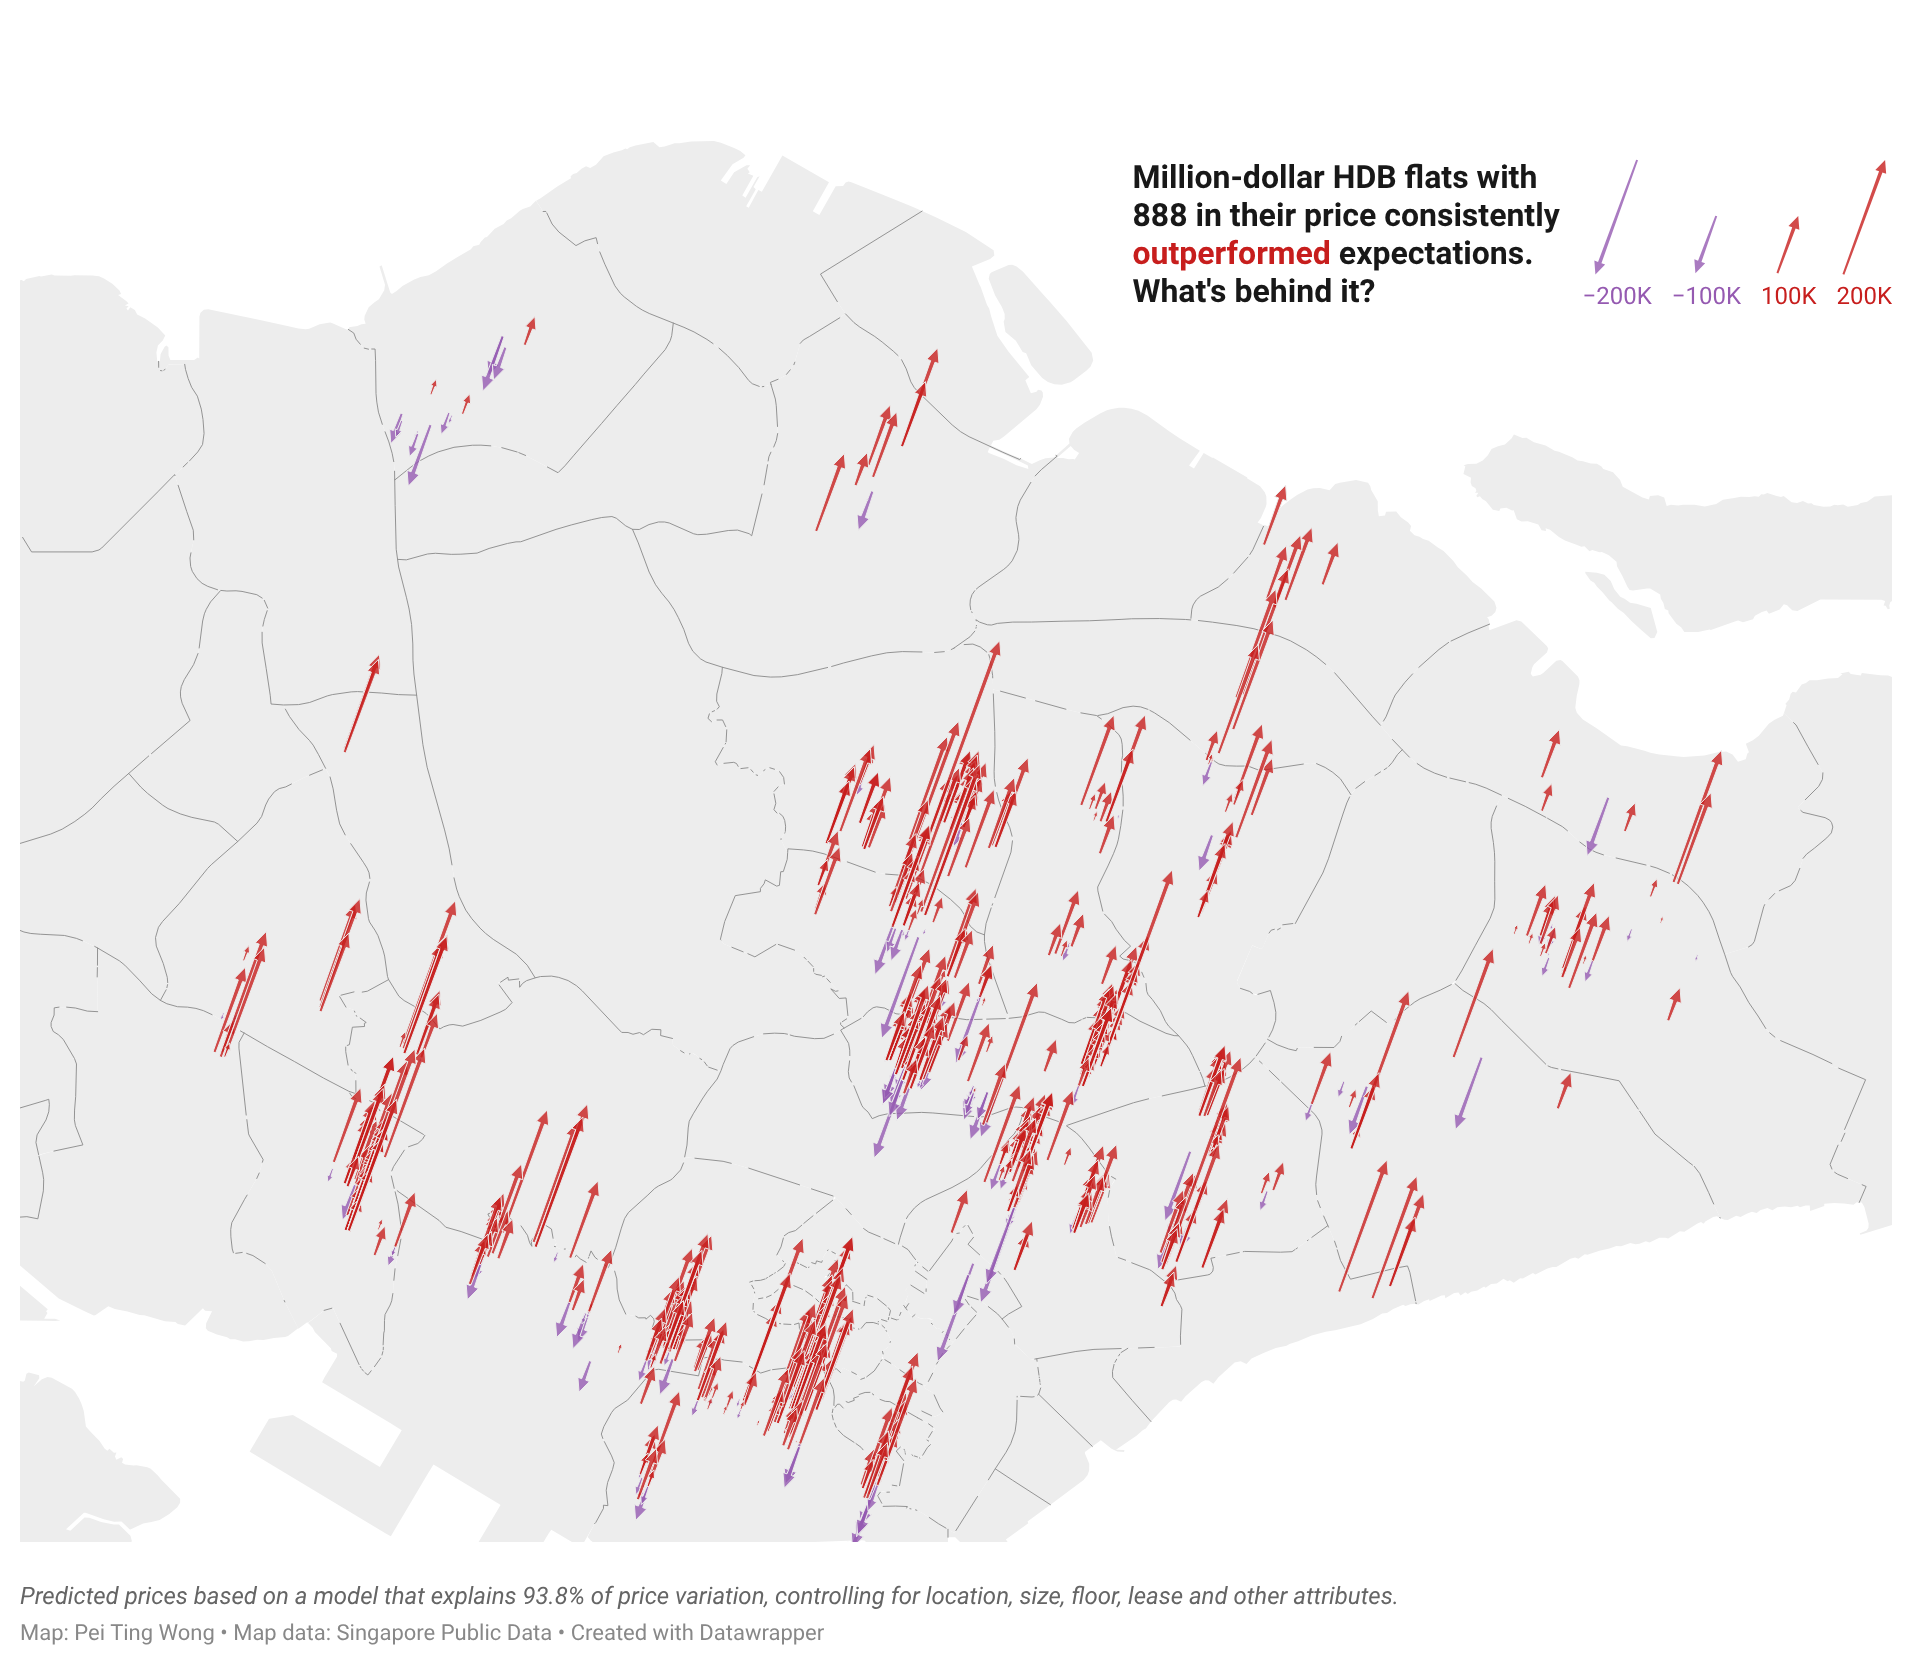

In [36]:
# final chart reproduced in Datawrapper based off arrow_map_million
from IPython.display import Image
Image(filename='charts/datawrapper_million.png')

# interactive version: https://www.datawrapper.de/_/nufg7/